In [1]:
from src import *

- Initialisation of the hyperparameters 

In [2]:
L = 40  # 0, 0.1, ..., 1.0
nrep = 100
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

### Tuning of the parameters $k_\lambda$ and $m_\lambda$ over a uniform grid of size $L$

Lambda grid: 100%|██████████| 41/41 [00:00<00:00, 47.19it/s]


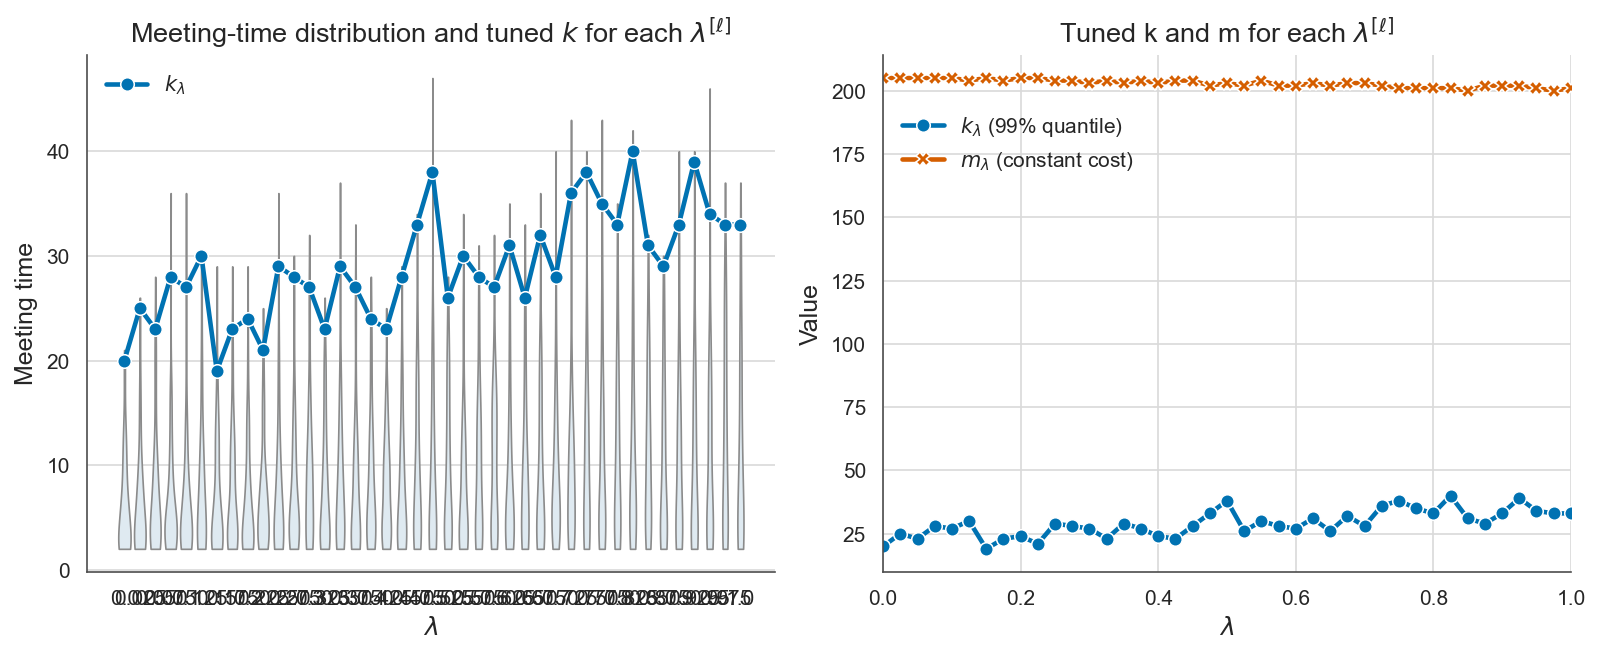

In [3]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, nrep = nrep)

### Variance of the UMCMC estimator and the second moment over the grid 
- $\hat{E}(\lambda)$ is the UMCMC of the expectation $\mathbb{E}_{\pi_\lambda}[\nabla_\lambda \log \pi_\lambda]$

Final estimation: 100%|██████████| 41/41 [00:11<00:00,  3.42it/s]


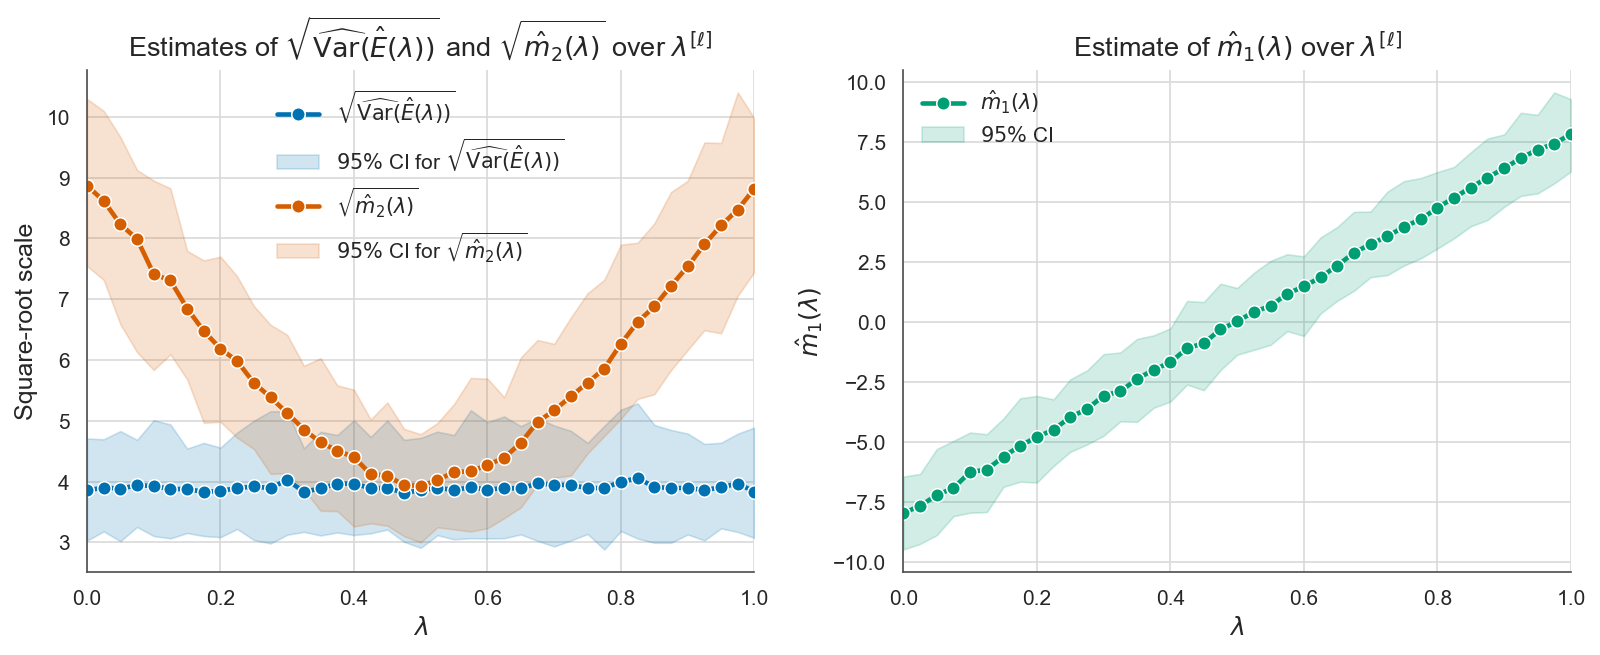

In [4]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag)

### Now try various startified estimators 

In [5]:


def random_budget_allocation(L, M):
    if M < L:
        raise ValueError("M must be at least L so each bin gets at least one sample.")

    # Give one sample to each bin, then distribute the remaining budget randomly.
    budget = np.ones(L, dtype=int)
    remaining = M - L

    if remaining > 0:
        extra = np.random.multinomial(remaining, np.ones(L) / L)
        budget += extra

    return budget



- For a fixed budget of M

In [3]:
M = 100
alpha = 0.8
L = int(np.floor(M**alpha))
L_initial = M//2
L_final = M 

In [4]:
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, nrep = nrep)
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]

Lambda grid: 100%|██████████| 40/40 [00:00<00:00, 47.36it/s]


In [5]:
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag)
budget = build_budget(L, M, estimator)

In [ ]:
estimators = [
    lambda: stratified_estimator_splitting(L_final, estimator, initial_L=L_initial, n_samples=5),
    lambda: optimal_startified_estimator(0.8, M, budget, estimator)
]

labels = ["Spliting", "optimal scheme"]

xp1 = plot_estimators_box_CI(
    estimators,
    labels,
    nrep=100,
    ci_level=0.95,
)


ValueError: estimators and labels must have the same length.

In [ ]:
lambda: stratified_estimator_indepdent(L, budget, estimator),
    lambda: stratified_estimator_crn(L, budget, estimator),
lambda: propo_startified_estimator(0.8, M, estimator)

In [ ]:
M = 100
alpha = 0.8
L = int(np.floor(M**alpha))
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, nrep = nrep)
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
res = estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag)
sqrt_m2 = np.sqrt(res["m2"])

Final estimation: 100%|██████████| 40/40 [00:10<00:00,  3.66it/s]


In [ ]:
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag)

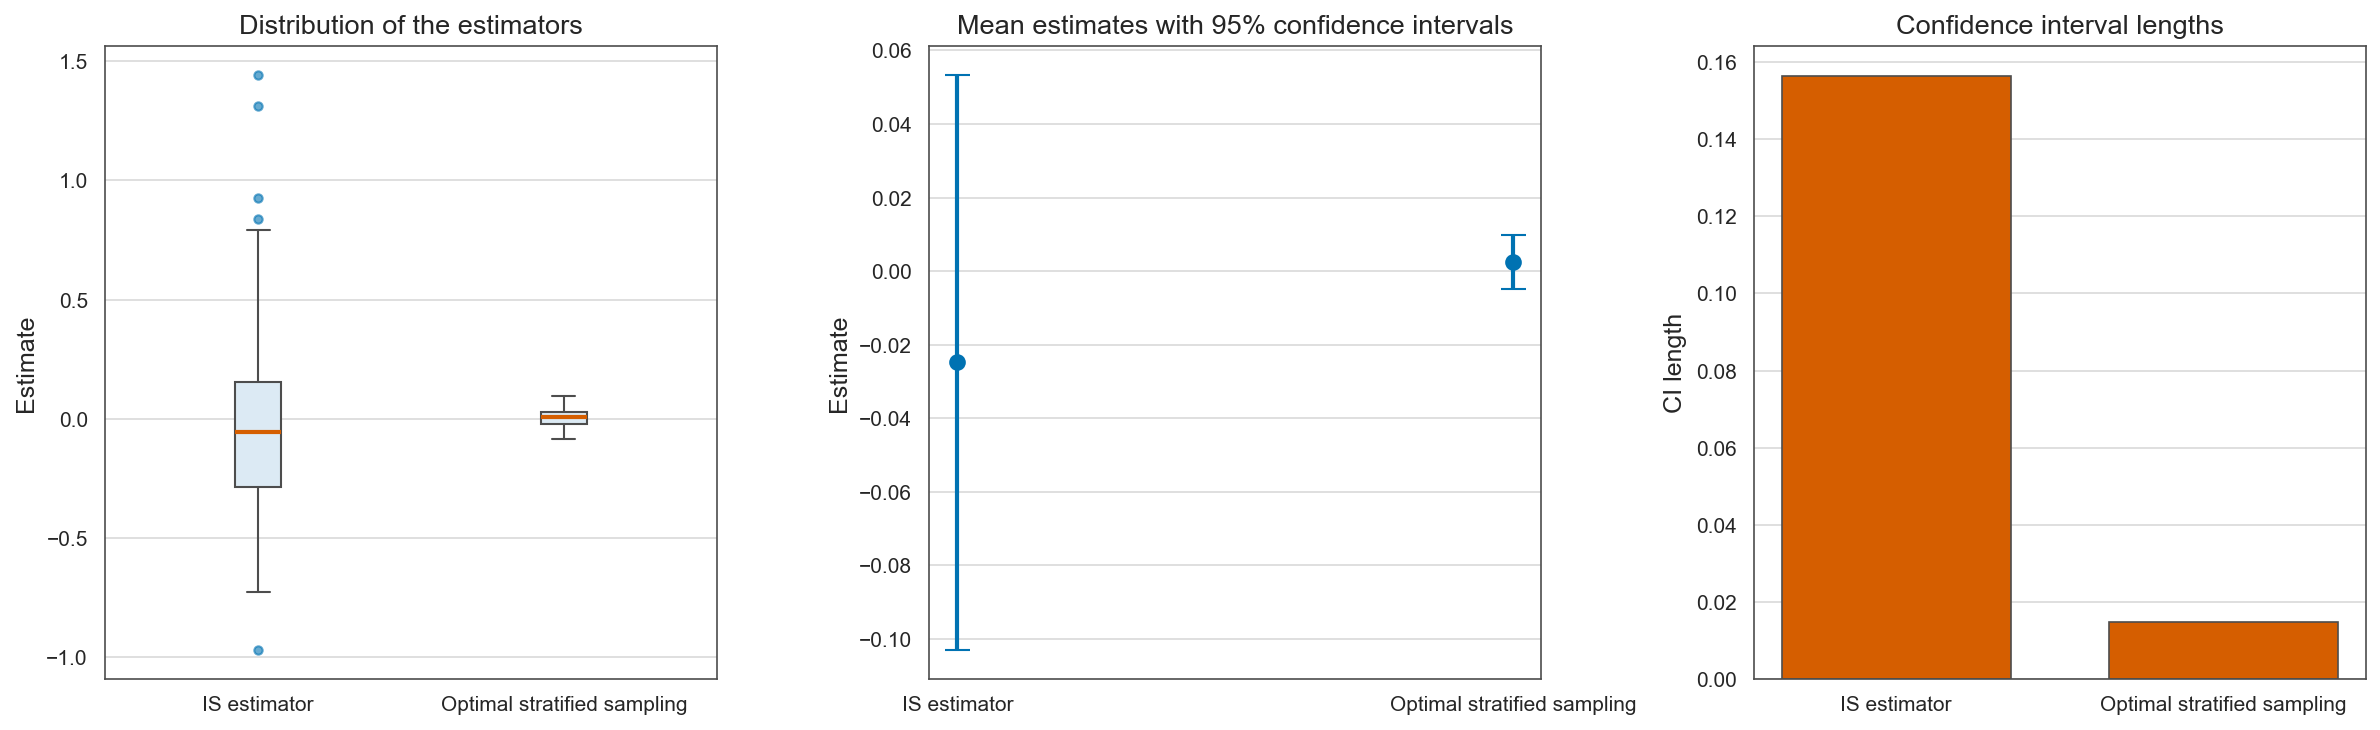

IS estimator: CI length = 0.156421
Optimal stratified sampling: CI length = 0.014597


In [ ]:
estimators = [
    lambda: q_unbiased_estimator(L, M, estimator, sqrt_m2), lambda: optimal_startified_estimator(0.8, M, estimator)
]
labels = [ "IS estimator", "Optimal stratified estimator" ]

xp1 = plot_estimators_box_CI(
    estimators,
    labels,
    nrep=100,
    ci_level=0.95,
)